## Problem Statement

You work for a fitness company and have gathered data on the fitness activities of 50 individuals using fitness trackers. The dataset is stored in an Excel file named "fitness_data.xlsx" and includes the following columns:

- **name:** Name of the person.
- **steps_taken:** The number of steps taken by individuals.
- **calories_burned:** The estimated calories burned by individuals.
- **sleep_duration(hours):** The number of hours of sleep individuals got on that day.
- **water_intake(ounces):** The amount of water individuals consumed.


**Import Necessary Libraries**

## Task1

1. Import the data from the "fitness_data.xlsx" Excel file.
2. Display the first few rows of the dataset to get an overview.
3. Calculate and display basic statistics (mean, median, min, max) for each column.


In [5]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_excel("fitness_data.xlsx")
print(df.shape)
df.head()

(50, 5)


,name,steps_taken,calories_burned,sleep_duration(hours),water_intake(ounces)
0,Akshay,10500,4500,7.5,80
1,Priya,9800,4200,7.2,75
2,Raj,11500,4800,7.0,90
3,Emily,12000,5000,7.8,85
4,Rohit,8900,4000,7.0,70


## Task2:  Range and IQR

1. Calculate the range of "steps_taken".
2. Calculate the range of "calories_burned".
3. Calculate the Interquartile Range (IQR) for "sleep_duration(hours)".
4. Calculate the IQR for "water_intake(ounces)".

In [12]:
# Calculate the range of "steps_taken" for the entire week
steps_taken_range = df["steps_taken"].max() - df["steps_taken"].min()

# Calculate the range of "calories_burned" for the entire week
calories_burned_range = df["calories_burned"].max() - df["calories_burned"].min()
# Calculate the Interquartile Range (IQR) for "sleep_duration(hours)"
sleep_duration_iqr = df["sleep_duration(hours)"].quantile(0.75) - df["sleep_duration(hours)"].quantile(0.25)

# Calculate the IQR for "water_intake(ounces)"
water_intake_iqr = df["water_intake(ounces)"].quantile(0.75) - df["water_intake(ounces)"].quantile(0.25)

# Print the results
print("Range of Steps Taken:", steps_taken_range)
print("Range of Calories Burned:", calories_burned_range)
print("IQR of Sleep Duration:", sleep_duration_iqr)
print("IQR of Water Intake:", water_intake_iqr)

Range of Steps Taken: 7000
Range of Calories Burned: 1800
IQR of Sleep Duration: 0.5
IQR of Water Intake: 20.0


## Task3: Box Plot for Steps Taken

- Create a box plot for the "steps_taken" column to visualize the distribution of daily steps taken by individuals. Interpret the box plot and identify any outliers.

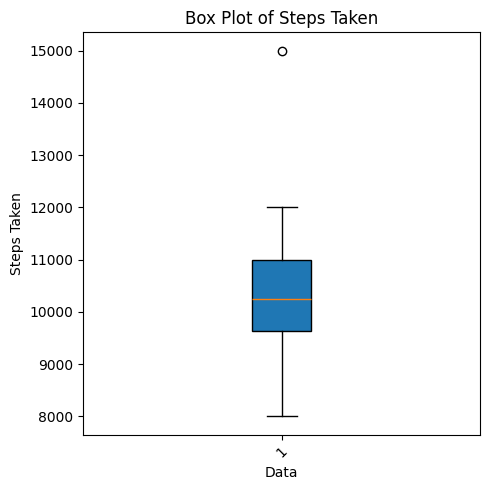

In [13]:
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(5, 5))

# Create a box plot for "Steps Taken"
plt.boxplot(df["steps_taken"], vert=True, patch_artist=True)

# Set the title and labels
plt.title('Box Plot of Steps Taken')
plt.xlabel('Data')
plt.ylabel('Steps Taken')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Ensure proper layout and display the plot
plt.tight_layout()
plt.show()

#### Observations

- Most individuals appear to have a median daily step count around 10,000 as indicated by the orange line within the box.
- The presence of an outlier at 15,000 indicates that there is at least one individual who took an exceptionally high number of steps. This could be due to various reasons, such as an unusually active day or a measurement error.


## Task4: 

- Use the IQR method to identify and label outliers in the "sleep_duration(hours)" column.

In [14]:
#defininig the function
def get_lower_upper(data):
    Q1, Q3 = data["sleep_duration(hours)"].quantile([0.25,0.75])
    IQR = Q3-Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    return lower, upper


In [15]:
#get the lower and upper limits
lower, upper = get_lower_upper(df)
lower, upper

(6.25, 8.25)

In [16]:
# Identify and label outliers
outliers = df[(df["sleep_duration(hours)"] < lower ) | (df["sleep_duration(hours)"] > upper)]


# Display the outliers
outliers

,name,steps_taken,calories_burned,sleep_duration(hours),water_intake(ounces)
21,Elena,11700,4900,18.0,100
30,Siddharth,11300,4700,4.0,75
